## Step 1 : Download data of Interest

We will use data dowloaded from yfinance. The data we download is from the Hotel industry. We download 5 different stocks for this project which are : \
    - Booking.com \
    - Hyatt \
    - Hilton \
    - Mariott \
    - IHG

In [1]:
from main import Fetch_Data
from main import Select_Pair
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_5_series


In [2]:
start_date = '2010-01-01'
end_date = '2025-02-01'
tickers = ['IHG', 'HLT', 'MAR', 'BKNG', 'H']

In [3]:
fetcher = Fetch_Data(start_date,end_date,tickers)
data = fetcher.download_data()

/Users/mpecaut/Empirical-Methods-In-Finance/Project1/main.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.tickers, start = self.start_date, end = self.end_date)
[*********************100%***********************]  5 of 5 completed


In [4]:
data = data['Close']

In [5]:
data

Ticker,BKNG,H,HLT,IHG,MAR
Date,,,,,
2010-01-04,220.354431,29.003143,NaN,12.650038,21.998896
2010-01-05,222.912567,29.041866,NaN,12.562916,22.126282
2010-01-06,215.552994,28.770803,NaN,12.510647,22.189989
2010-01-07,212.650497,28.935375,NaN,12.641327,22.277573
2010-01-08,212.729202,28.761120,NaN,12.885268,22.325335
...,...,...,...,...,...
2025-01-27,4640.876953,155.312515,249.033859,127.680603,284.715149
2025-01-28,4650.128418,157.393707,252.963074,130.036591,285.298370
2025-01-29,4687.034180,156.786285,253.232315,130.591507,286.306549


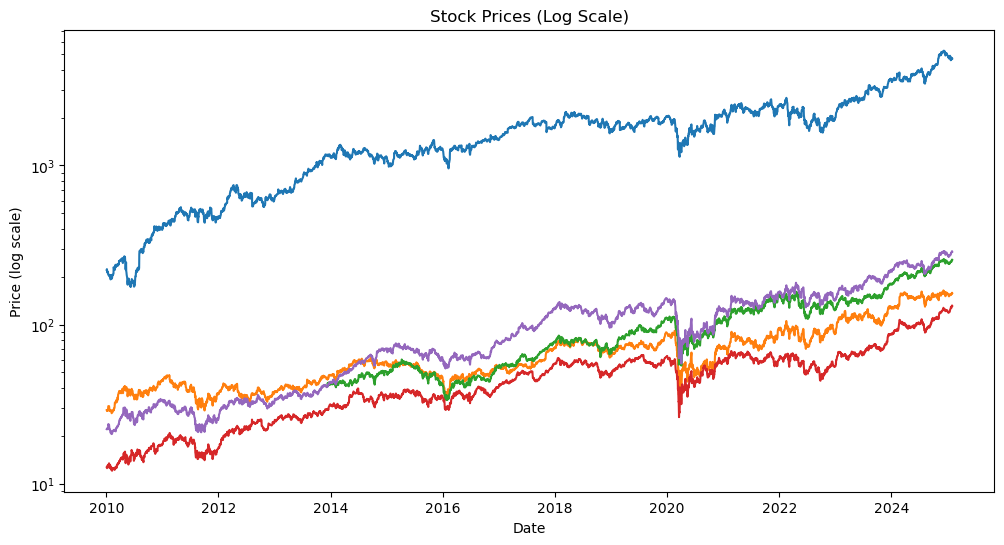

In [6]:
plot_5_series(data,'Stock Prices (Log Scale)','log', 'Date', 'Price (log scale)')

## Stationarity 

Stationarity means that the 2 first moments are constant through time, i.e mean and variance exhibit no time-dependence. Ultimately, if my asset is stationary, it means it exhibits no trends or seasonal effects. It is important to differentiate the cointegration from the correlation. Two assets are correlated in the sense that if one moves up, the other will certainly also move up by some amount. However, this might not imply that the spread between those 2 assets is constant. Indeed, it might even diverge. This is where cointegration comes into play. If two assets are cointegrated, then the spread (the price difference between the 2 assets) will remain constant through time. This implies that if the spread diverges (goes above or below its normal level), in theory, it should not be long before this value comes back to its average level. This is what we will exploit later on.

In [7]:
data = np.log(data)
data

Ticker,BKNG,H,HLT,IHG,MAR
Date,,,,,
2010-01-04,5.395237,3.367404,NaN,2.537660,3.090992
2010-01-05,5.406780,3.368738,NaN,2.530749,3.096766
2010-01-06,5.373207,3.359361,NaN,2.526580,3.099641
2010-01-07,5.359650,3.365065,NaN,2.536971,3.103580
2010-01-08,5.360020,3.359024,NaN,2.556085,3.105722
...,...,...,...,...,...
2025-01-27,8.442659,5.045439,5.517589,4.849532,5.651489
2025-01-28,8.444650,5.058750,5.533244,4.867816,5.653536
2025-01-29,8.452555,5.054884,5.534307,4.872074,5.657063


In [8]:
pairselect = Select_Pair(data)
permut = pairselect.permutations()

In [ ]:
pairselect.are

[('BKNG', 'H'), ('BKNG', 'HLT'), ('BKNG', 'IHG'), ('BKNG', 'MAR'), ('H', 'BKNG'), ('H', 'HLT'), ('H', 'IHG'), ('H', 'MAR'), ('HLT', 'BKNG'), ('HLT', 'H'), ('HLT', 'IHG'), ('HLT', 'MAR'), ('IHG', 'BKNG'), ('IHG', 'H'), ('IHG', 'HLT'), ('IHG', 'MAR'), ('MAR', 'BKNG'), ('MAR', 'H'), ('MAR', 'HLT'), ('MAR', 'IHG')]
Date
2010-01-04    5.395237
2010-01-05    5.406780
2010-01-06    5.373207
2010-01-07    5.359650
2010-01-08    5.360020
                ...   
2025-01-27    8.442659
2025-01-28    8.444650
2025-01-29    8.452555
2025-01-30    8.463606
2025-01-31    8.455875
Name: BKNG, Length: 3794, dtype: float64
Date
2010-01-04    3.367404
2010-01-05    3.368738
2010-01-06    3.359361
2010-01-07    3.365065
2010-01-08    3.359024
                ...   
2025-01-27    5.045439
2025-01-28    5.058750
2025-01-29    5.054884
2025-01-30    5.065308
2025-01-31    5.059825
Name: H, Length: 3794, dtype: float64
----------------
Date
2010-01-04    5.395237
2010-01-05    5.406780
2010-01-06    5.373207
2

data